In [1]:
import pandas as pd
import sqlite3

In [2]:
connect = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
query = """
    SELECT timestamp
    FROM checker
    WHERE uid LIKE "user_%"
"""
df = pd.read_sql(query, connect, parse_dates=['timestamp'])

In [4]:
df['date'] = df['timestamp'].dt.date
df['day_of_week'] = df['timestamp'].dt.weekday
df['hour'] = df['timestamp'].dt.hour
df['is_weekend'] = df['day_of_week'].isin([5, 6])
df['hour_label'] = df['timestamp'].dt.strftime('%a, %H-%M').str[:-3]

commits_count = df.groupby(['date', 'day_of_week', 'hour', 'is_weekend']).size().reset_index(name='commits')
commits_count = commits_count.drop(commits_count[commits_count['commits'] == 0].index)
commits_count

,date,day_of_week,hour,is_weekend,commits
0,2020-04-17,4,5,False,13
1,2020-04-17,4,11,False,8
2,2020-04-17,4,12,False,2
3,2020-04-18,5,7,True,1
4,2020-04-18,5,13,True,5
...,...,...,...,...,...
283,2020-05-21,3,16,False,4
284,2020-05-21,3,17,False,1
285,2020-05-21,3,18,False,2
286,2020-05-21,3,19,False,8


In [5]:
work_days = commits_count[-commits_count['is_weekend']]
weekends = commits_count[commits_count['is_weekend']]

work_days_avg = work_days.groupby(work_days['hour'])['commits'].mean()
weekends_avg = weekends.groupby(weekends['hour'])['commits'].mean()

result = pd.DataFrame()
result['weekend'] = weekends_avg
result['working_day'] = work_days_avg

In [6]:
full_index = range(24)

result_full = result.reindex(full_index, fill_value=0)
result_full

,weekend,working_day
hour,,
0,2.000000,3.000000
1,6.000000,NaN
2,0.000000,0.000000
3,1.000000,2.000000
4,0.000000,0.000000
5,2.000000,7.500000
6,0.000000,0.000000
7,4.000000,5.166667
8,7.000000,3.700000


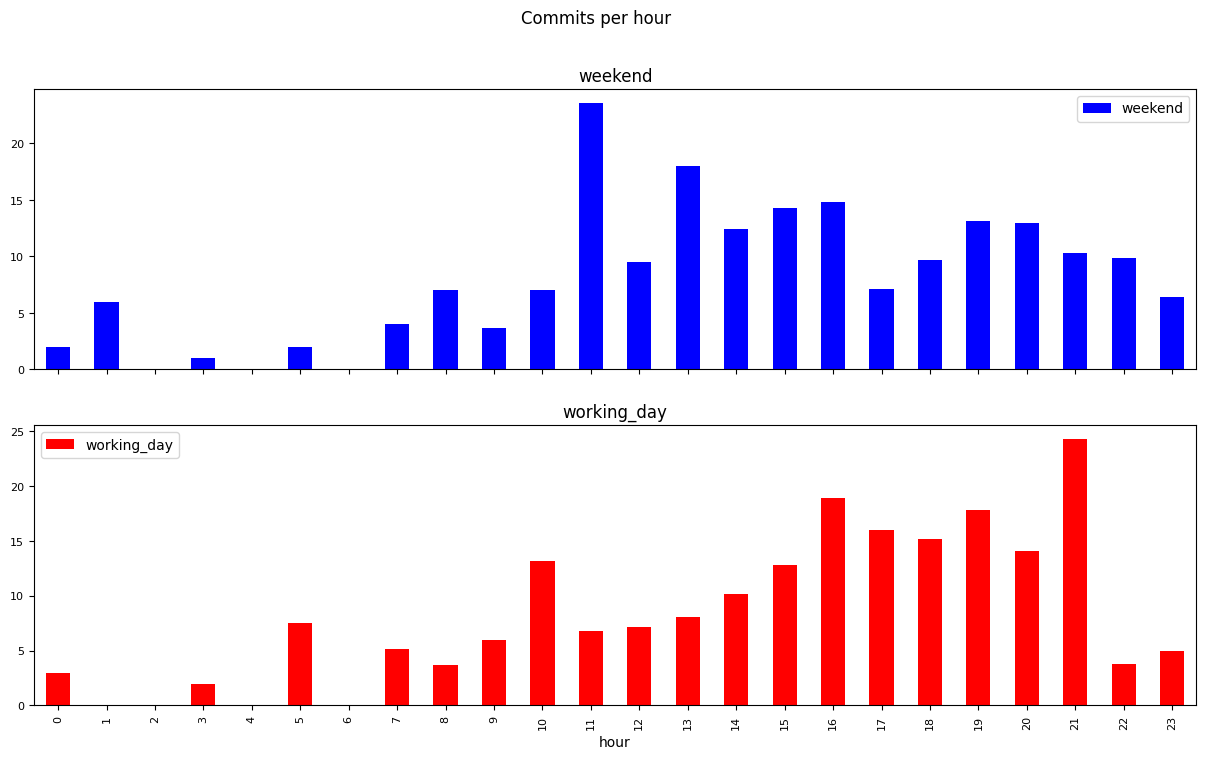

In [7]:
result_full.plot(kind='bar',
            fontsize=8,
            figsize=(15,8),
            rot= 90,
            subplots=True,
            title='Commits per hour',
            color=['blue','red'],
            
           );

In [8]:
connect.close()

## 21 - рабочий день , 11 - выходной день